In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#set main paths
CUR_DIR = os.path.dirname(os.path.abspath(__name__))
print(CUR_DIR)
DATA_DIR = CUR_DIR+'/data/human_annotation/'


/Users/anna/Dropbox/2023_AOI/MoralLearning/CodeSets/graph_extract


In [4]:
scenario = 1
choice = 1

### some function definitions for analysis

In [5]:
def compute_reliability(value_data):
    """
    Compute inter-rater reliability using correlation.
    
    Parameters:
    value_data (DataFrame): DataFrame containing annotator scores.
    
    Returns:
    float: Mean correlation between annotators.
    """
    # Select columns starting with 'p' for annotator scores
    annotator_columns = [col for col in value_data.columns if col.startswith('p')]
    annotator_data = value_data[annotator_columns].values
    
    # Compute all pairwise correlations
    correlations = np.corrcoef(annotator_data, rowvar=False)
    
    # Take the upper triangle of the correlation matrix
    upper_triangle_indices = np.triu_indices_from(correlations, k=1)
    
    # Extract the upper triangle values
    upper_triangle_values = correlations[upper_triangle_indices]
    
    # Take the mean of the upper triangle values
    mean_correlation = np.mean(upper_triangle_values)


    print(f"Mean correlation between annotators: {mean_correlation:.2f}")
    
    return mean_correlation


### Value Scores

##### show the data

In [6]:
filename_value_scores = f"{DATA_DIR}scenarios_{scenario}_choice_{choice}_value_scores.csv"
value_data = pd.read_csv(filename_value_scores, usecols=lambda column: column != 'Unnamed: 0')
value_data
#figures are already saved in the Results folder

,value_names,annotator_scores,p1,p2,p3,p4,p5,p6,p8,mean,se_mean,mean_dist,se_mean_dist,mean_abs_dist,values_missing
0,loyalty,80,76,4,45,90,61,23,70,52.714286,12.489361,-27.285714,12.489361,30.142857,"pity,pity,yes he is a liar,Pity,Lack of courage"
1,compassion,90,73,19,100,90,89,93,70,76.285714,11.209406,-13.714286,11.209406,17.428571,"pity,pity,yes he is a liar,Pity,Lack of courage"
2,supportiveness,90,82,90,81,100,100,84,70,86.714286,4.426651,-3.285714,4.426651,9.000000,"pity,pity,yes he is a liar,Pity,Lack of courage"
3,empathy,80,74,82,100,100,79,100,75,87.142857,5.024543,7.142857,5.024543,10.571429,"pity,pity,yes he is a liar,Pity,Lack of courage"
4,commitment,80,61,10,80,61,53,59,70,56.285714,9.060642,-23.714286,9.060642,23.714286,"pity,pity,yes he is a liar,Pity,Lack of courage"
5,kindness,90,20,37,90,90,74,91,70,67.428571,11.546662,-22.571429,11.546662,22.857143,"pity,pity,yes he is a liar,Pity,Lack of courage"
6,responsibility,70,22,23,78,100,78,29,60,55.714286,12.794778,-14.285714,12.794778,27.428571,"pity,pity,yes he is a liar,Pity,Lack of courage"
7,neglect,0,97,86,0,0,29,8,10,32.857143,16.876066,32.857143,16.876066,32.857143,"pity,pity,yes he is a liar,Pity,Lack of courage"
8,indifference,0,85,82,0,0,56,21,30,39.142857,14.625755,39.142857,14.625755,39.142857,"pity,pity,yes he is a liar,Pity,Lack of courage"
9,selfishness,0,100,95,11,18,59,11,20,44.857143,16.147632,44.857143,16.147632,44.857143,"pity,pity,yes he is a liar,Pity,Lack of courage"


#### report inter-rater agreement and correlation with annotator

In [7]:
#report overall correlation between annotator_scores and mean
correlation = np.corrcoef(value_data['annotator_scores'], value_data['mean'])[0, 1]
print(f"Correlation between annotator scores and mean scores: {correlation:.2f}")
compute_reliability(value_data)
#compute the mean absolute distance by taking the mean in the value_data
print(f"Mean absolute distance from annotator scores: {np.mean(value_data['mean_abs_dist']):.2f}")

Correlation between annotator scores and mean scores: 0.80
Mean correlation between annotators: 0.21
Mean absolute distance from annotator scores: 25.80


### Outcome Likelihood Ratings

In [8]:
filename_outcome_scores = f"{DATA_DIR}scenarios_{scenario}_choice_{choice}_outcomes.csv"
outcome_data = pd.read_csv(filename_outcome_scores, usecols=lambda column: column != 'Unnamed: 0')
outcome_data

,outcome,p1,p2,p3,p4,p5,p6,p8,mean,se_mean
0,I continue to provide financial support for li...,100,81,78,100,20,87,75,77.285714,11.089821
1,I continue to assist with transportation to sc...,100,73,83,100,19,68,80,74.714286,11.214362
2,I continue to do the majority of the cooking.,83,97,77,80,58,72,80,78.142857,4.804099
3,My girlfriend continues to rely on me for supp...,100,87,76,90,31,87,90,80.142857,9.301818
4,My girlfriend may delay becoming fully indepen...,19,100,67,95,63,70,80,70.571429,10.905802
5,I may experience ongoing feelings of guilt.,100,100,100,100,100,88,90,96.857143,2.203893
6,My girlfriend remains unaware of my true feeli...,100,77,31,100,26,92,80,72.285714,12.751284
7,My relationship continues without a future com...,82,100,100,10,70,74,80,73.714286,12.431399


In [9]:
print(f"Mean ratings (100 is correct): {np.mean(outcome_data['mean']):.2f}")

Mean ratings (100 is correct): 77.96


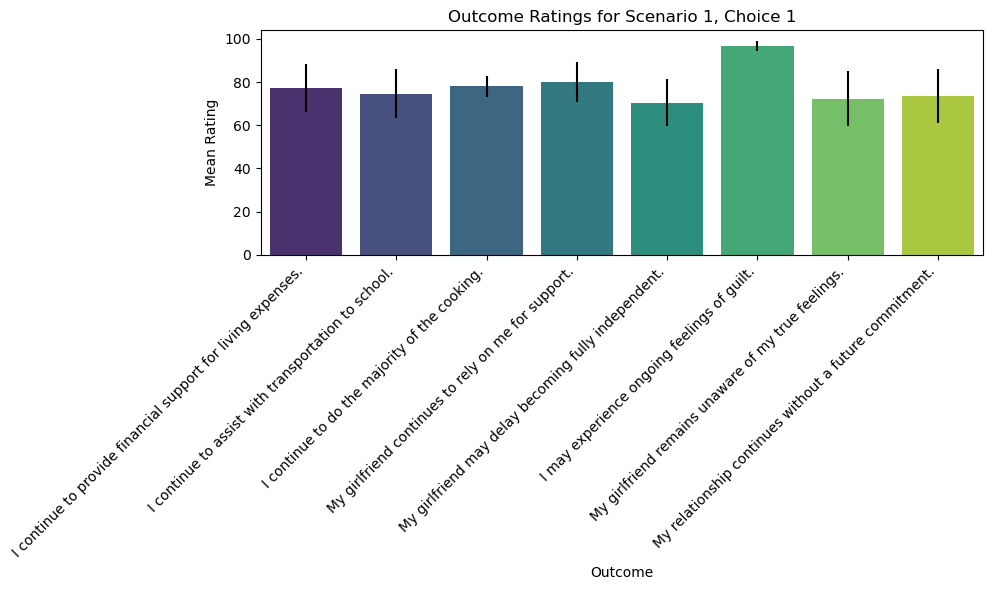

In [10]:
#select only mean and se_mean columns
outcome_data_simple = outcome_data[['outcome','mean', 'se_mean']]

#plot the outcome data using outcome as the x-axis and mean as the y-axis, with se_mean as the error bars
#add a legend for the x axis labels along the right side of the plot
plt.figure(figsize=(10, 6))
sns.barplot(x='outcome', y='mean', data=outcome_data_simple, yerr=outcome_data_simple['se_mean'], capsize=0.1, palette='viridis')
plt.xlabel('Outcome')
plt.ylabel('Mean Rating')
plt.xticks(rotation=45, ha='right')
plt.title(f'Outcome Ratings for Scenario {scenario}, Choice {choice}')
plt.tight_layout()
plt.show()

### Outcome Utilities

In [11]:
filename_util_scores = f"{DATA_DIR}scenarios_{scenario}_choice_{choice}_outcome_utilities.csv"
util_data = pd.read_csv(filename_util_scores, usecols=lambda column: column != 'Unnamed: 0')
util_data

,annot_scores,p1,p2,p3,p4,p5,p6,p8,entity,outcome,subj_means,subj_se
0,-30,-100,61,-42,-100,-100,-34,-20,I,I continue to provide financial support for li...,-47.857143,24.157387
1,80,100,42,63,100,100,74,75,my girlfriend,I continue to provide financial support for li...,79.142857,9.111740
2,20,-100,46,-25,-100,-70,-33,-30,I,I continue to assist with transportation to sc...,-44.571429,20.899039
3,0,100,24,27,100,-74,69,75,my girlfriend,I continue to assist with transportation to sc...,45.857143,24.970459
4,-30,-64,-53,-25,-80,26,-49,-50,I,I continue to do the majority of the cooking.,-42.142857,14.018695
5,50,82,-85,0,100,-40,77,75,my girlfriend,I continue to do the majority of the cooking.,29.857143,29.279713
6,0,-100,62,-31,-100,-13,-43,-20,I,My girlfriend continues to rely on me for supp...,-35.000000,22.759613
7,50,100,64,49,100,-15,62,60,my girlfriend,My girlfriend continues to rely on me for supp...,60.000000,15.781494
8,0,-80,-100,-100,-100,-34,-53,0,I,My girlfriend may delay becoming fully indepen...,-66.714286,15.994295
9,-20,36,-100,-100,-100,-36,-20,-40,my girlfriend,My girlfriend may delay becoming fully indepen...,-51.428571,21.132988


/var/folders/4g/x09k0pjs3lv174fn9g0511840000gn/T/ipykernel_7262/3398453052.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='outcome', y='subj_means', hue='entity', data=util_data_simple, ci=None, capsize=0.1, palette='magma')


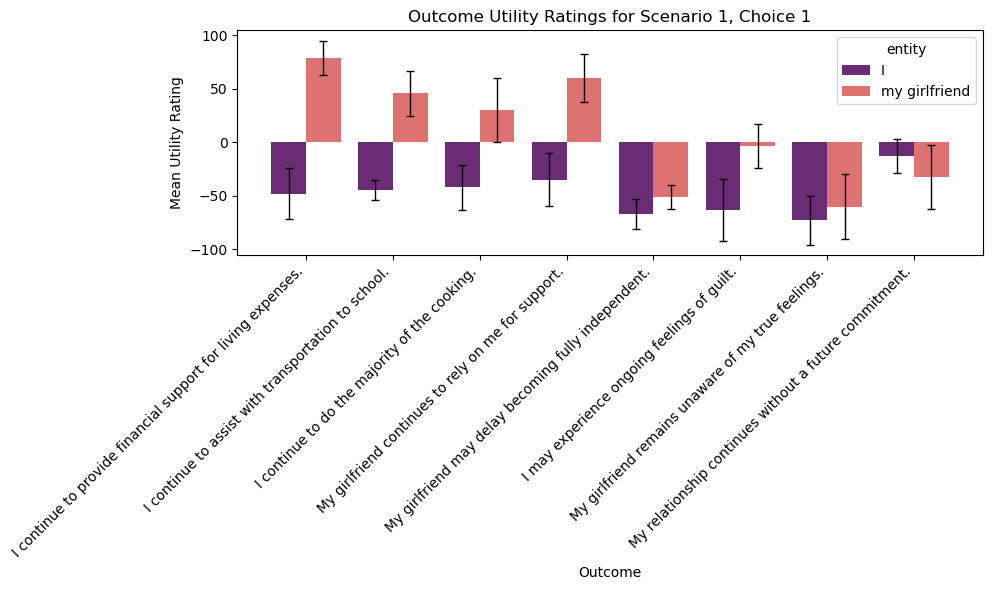

In [12]:
#create a bar plot of the outcome ratings with separate bars for each entity, and using subj_means as the y-axis and subj_se as the error bars
util_data_simple = util_data[['outcome', 'entity', 'subj_means', 'subj_se']]
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='outcome', y='subj_means', hue='entity', data=util_data_simple, ci=None, capsize=0.1, palette='magma')

# Add error bars manually
for i, (bar, (_, row)) in enumerate(zip(ax.patches, util_data_simple.iterrows())):
	# Get the bar position
	x = bar.get_x() + bar.get_width() / 2
	y = bar.get_height()
	err = row['subj_se']
	ax.errorbar(x, y, yerr=err, fmt='none', c='black', capsize=3, linewidth=1)

plt.xlabel('Outcome')
plt.ylabel('Mean Utility Rating')
plt.xticks(rotation=45, ha='right')
plt.title(f'Outcome Utility Ratings for Scenario {scenario}, Choice {choice}')
plt.tight_layout()
plt.show()

In [13]:
correlation = np.corrcoef(util_data['annot_scores'], util_data['subj_means'])[0, 1]
print(f"Correlation between annotator scores and mean scores: {correlation:.2f}")
compute_reliability(util_data)

Correlation between annotator scores and mean scores: 0.78
Mean correlation between annotators: 0.43


0.43488855257731174

### Outcome Links

In [14]:
filename_links = f"{DATA_DIR}scenarios_{scenario}_choice_{choice}_outcome_links.csv"
links_data = pd.read_csv(filename_links, usecols=lambda column: column != 'Unnamed: 0')
links_data

,outcome_name,link_type,annot_links,p1,p2,p3,p4,p5,p6,p8,subj_mean,agreement_percentage,subj_se
0,I continue to provide financial support for li...,Cause,1,0,1,1,0,1,1,1,0.714286,0.714286,0.199205
1,I continue to provide financial support for li...,Intend,1,0,0,0,0,1,1,0,0.285714,0.285714,0.199205
2,I continue to provide financial support for li...,Expect,1,0,0,1,1,1,1,1,0.714286,0.714286,0.199205
3,I continue to assist with transportation to sc...,Cause,1,0,0,1,1,1,0,1,0.571429,0.571429,0.218218
4,I continue to assist with transportation to sc...,Intend,1,0,0,0,0,1,1,1,0.428571,0.428571,0.218218
5,I continue to assist with transportation to sc...,Expect,1,0,0,1,0,1,1,1,0.571429,0.571429,0.218218
6,I continue to do the majority of the cooking.,Cause,1,1,0,1,1,0,1,1,0.714286,0.714286,0.199205
7,I continue to do the majority of the cooking.,Intend,1,0,1,0,0,0,0,1,0.285714,0.285714,0.199205
8,I continue to do the majority of the cooking.,Expect,1,1,0,1,0,0,1,1,0.571429,0.571429,0.218218
9,My girlfriend continues to rely on me for supp...,Cause,1,1,0,0,1,1,0,1,0.571429,0.571429,0.218218


In [15]:
#print the mean agreement percentage
mean_agreement = np.mean(links_data['agreement_percentage'])
print(f"Mean agreement percentage: {mean_agreement:.2f}")
#computer interrater reliability using spearman rank



data_raters = links_data[[col for col in links_data.columns if col.startswith('p')]]
def compute_reliability_rank(data_raters):
    # Compute the Spearman rank correlation for each pair of annotators
    corr_matrix = data_raters.corr(method='spearman')
    # Extract the upper triangle of the correlation matrix
    upper_triangle_indices = np.triu_indices_from(corr_matrix, k=1)
    upper_triangle_values = corr_matrix.values[upper_triangle_indices]
    # Compute the mean of the upper triangle values
    mean_spearman_correlation = np.mean(upper_triangle_values)
    print(f"Mean Spearman rank correlation between annotators: {mean_spearman_correlation:.2f}")
   

compute_reliability_rank(data_raters)

Mean agreement percentage: 0.58
Mean Spearman rank correlation between annotators: 0.01


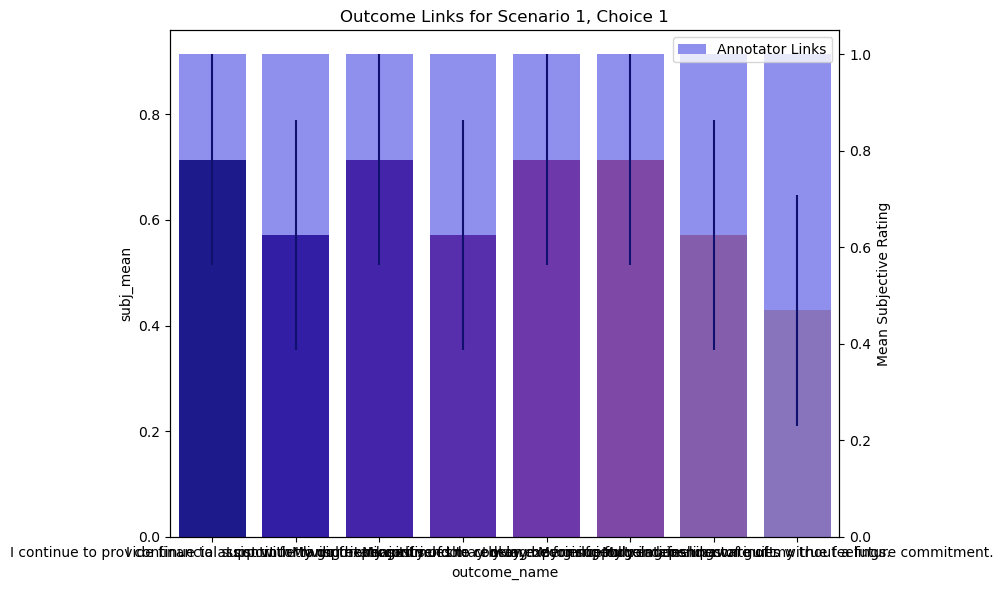

In [17]:
#select only the link types "cause" and make a plot showing subj_mean in a bar plot with error bars based on subj_se
#add a bar next to it showing the value of annot_links
links_data['annot_links'] = links_data['annot_links'].astype(float)  # Ensure annot_links is float for plotting
links_data['subj_mean'] = links_data['subj_mean'].astype(float)  # Ensure subj_mean is float for plotting
links_data['subj_se'] = links_data['subj_se'].astype(float)
links_data['outcome_name'] = links_data['outcome_name'].astype(str) 
links_data_cause = links_data[links_data['link_type'] == 'Cause']
links_data_cause_simple = links_data_cause[['outcome_name', 'subj_mean', 'subj_se', 'annot_links']]
plt.figure(figsize=(10, 6))
sns.barplot(x='outcome_name', y='subj_mean', data=links_data_cause_simple, yerr=links_data_cause_simple['subj_se'], capsize=2, palette='magma')

# Plot annot_links as a bar plot next to subj_mean bars, putting it to the right of the subj_mean bars
plt.twinx()  # Create a second y-axis
sns.barplot(x=links_data_cause_simple['outcome_name'], y=links_data_cause_simple['annot_links'], alpha=0.5, color='blue', label='Annotator Links')
plt.ylabel('Annotator Links')
plt.legend(loc='upper right')
plt.xlabel('Outcome')
plt.ylabel('Mean Subjective Rating')
plt.xticks(rotation=45, ha='right')
plt.title(f'Outcome Links for Scenario {scenario}, Choice {choice}')
plt.tight_layout()
plt.show()